# Quality KPI Dashboard

## Process Audit Decision

The objective is to identify the production plant where the next process audit should be carried out.

The decision is based on the two measures required by the case:

- absolute field defect frequency
- relative field defect frequency

Only Type11 and Type21 vehicles are considered.

A vehicle is classified as defective when the vehicle itself, an installed component, or an installed individual part is defective.

All results in this notebook are derived from the single final dataset `vehicle_quality.csv`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

MAIN = "#9ADCFB"
MID = "#66BCE6"
ACCENT = "#2F75B5"
DARK = "#1F4E78"

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
FINAL_FOLDER = Path("data/final")

vehicle_quality = pd.read_csv(
    FINAL_FOLDER / "vehicle_quality.csv",
    parse_dates=[
        "Produktionsdatum",
        "Fehlerhaft_Datum",
        "Zulassungsdatum"
    ]
)

required_columns = [
    "ID_Fahrzeug",
    "OEM",
    "Werksnummer_OEM",
    "ORT_OEM",
    "Fahrzeugtyp",
    "Fehlerhaft_Gesamt",
    "Fehlerhaft_Karosserie",
    "Fehlerhaft_Schaltung",
    "Fehlerhaft_Sitze",
    "Fehlerhaft_Motor"
]

missing_columns = [
    column
    for column in required_columns
    if column not in vehicle_quality.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("Rows:", f"{len(vehicle_quality):,}")
print("Columns:", len(vehicle_quality.columns))
print("Unique vehicles:", vehicle_quality["ID_Fahrzeug"].is_unique)
print(
    "Missing final defect status:",
    vehicle_quality["Fehlerhaft_Gesamt"].isna().sum()
)

Rows: 2,489,518
Columns: 48
Unique vehicles: True
Missing final defect status: 0


# Executive Overview

The audit decision starts with the two field-quality measures explicitly required by the task.

In [3]:
plant_names = {
    "GOETTINGEN": "Göttingen",
    "NUERNBERG": "Nürnberg",
    "BONN": "Bonn"
}

plant_order = [
    "Nürnberg",
    "Bonn",
    "Göttingen"
]

plant_kpi = (
    vehicle_quality
    .groupby(
        [
            "OEM",
            "Werksnummer_OEM",
            "ORT_OEM"
        ],
        as_index=False
    )
    .agg(
        Vehicles=(
            "ID_Fahrzeug",
            "size"
        ),
        Defective_Vehicles=(
            "Fehlerhaft_Gesamt",
            "sum"
        )
    )
)

plant_kpi["Plant"] = (
    plant_kpi["ORT_OEM"]
    .map(plant_names)
    .fillna(plant_kpi["ORT_OEM"])
)

plant_kpi["Defect_Rate_%"] = (
    plant_kpi["Defective_Vehicles"]
    / plant_kpi["Vehicles"]
    * 100
)

overview = (
    plant_kpi[
        [
            "Plant",
            "OEM",
            "Vehicles",
            "Defective_Vehicles",
            "Defect_Rate_%"
        ]
    ]
    .set_index("Plant")
    .loc[plant_order]
    .reset_index()
)

display(
    overview.style.format(
        {
            "Vehicles": "{:,.0f}",
            "Defective_Vehicles": "{:,.0f}",
            "Defect_Rate_%": "{:.2f}%"
        }
    )
)

,Plant,OEM,Vehicles,Defective_Vehicles,Defect_Rate_%
0,Nürnberg,OEM1,"1,186,298","1,041,102",87.76%
1,Bonn,OEM1,"790,866","693,991",87.75%
2,Göttingen,OEM2,"512,354","455,877",88.98%


# Required KPI 1 — Absolute Field Defect Frequency

This measure shows the absolute number of defective vehicles associated with each production plant.

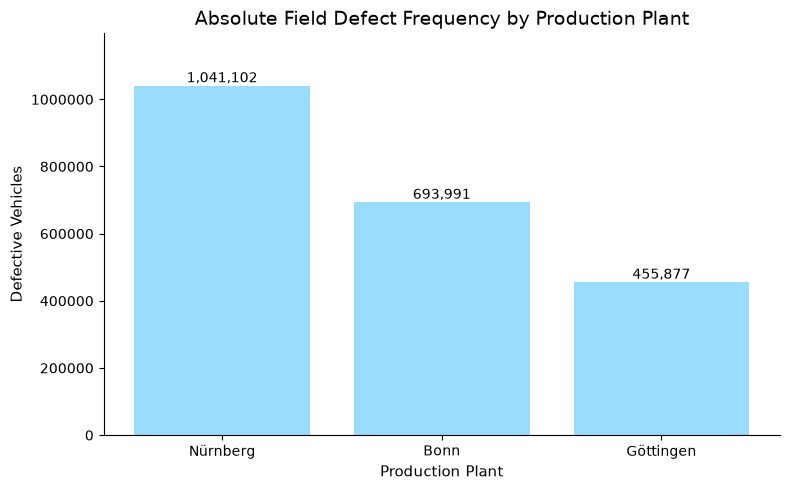

In [4]:
absolute_plot = (
    plant_kpi
    .set_index("Plant")
    .loc[plant_order]
    .reset_index()
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

bars = ax.bar(
    absolute_plot["Plant"],
    absolute_plot["Defective_Vehicles"],
    color=MAIN
)

ax.set_title(
    "Absolute Field Defect Frequency by Production Plant"
)

ax.set_xlabel(
    "Production Plant"
)

ax.set_ylabel(
    "Defective Vehicles"
)

ax.set_ylim(
    0,
    absolute_plot["Defective_Vehicles"].max() * 1.15
)

ax.ticklabel_format(
    style="plain",
    axis="y"
)

for bar, value in zip(
    bars,
    absolute_plot["Defective_Vehicles"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# Required KPI 2 — Relative Field Defect Frequency

This measure divides the number of defective vehicles by the total number of vehicles produced at each plant. It therefore accounts for differences in production volume.

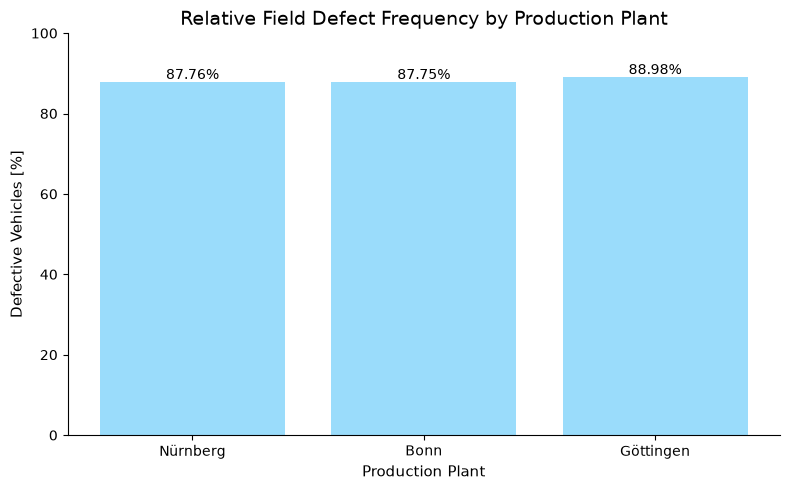

In [5]:
relative_plot = (
    plant_kpi
    .set_index("Plant")
    .loc[plant_order]
    .reset_index()
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

bars = ax.bar(
    relative_plot["Plant"],
    relative_plot["Defect_Rate_%"],
    color=MAIN
)

ax.set_title(
    "Relative Field Defect Frequency by Production Plant"
)

ax.set_xlabel(
    "Production Plant"
)

ax.set_ylabel(
    "Defective Vehicles [%]"
)

ax.set_ylim(
    0,
    100
)

for bar, value in zip(
    bars,
    relative_plot["Defect_Rate_%"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# Audit Decision from the Required KPIs

The absolute and relative measures answer different questions:

- the absolute frequency indicates the total field-quality burden
- the relative frequency indicates whether a plant has a disproportionately high share of defective vehicles

For a process-audit decision, the relative frequency is the more direct comparison of plant performance because it controls for production volume.

In [6]:
highest_absolute = plant_kpi.loc[
    plant_kpi["Defective_Vehicles"].idxmax()
]

highest_relative = plant_kpi.loc[
    plant_kpi["Defect_Rate_%"].idxmax()
]

decision_table = pd.DataFrame(
    {
        "Measure": [
            "Highest absolute field defect frequency",
            "Highest relative field defect frequency",
            "Initial audit candidate"
        ],
        "Result": [
            f"{highest_absolute['Plant']} — {highest_absolute['Defective_Vehicles']:,.0f} defective vehicles",
            f"{highest_relative['Plant']} — {highest_relative['Defect_Rate_%']:.2f}%",
            highest_relative["Plant"]
        ]
    }
)

display(decision_table)

,Measure,Result
0,Highest absolute field defect frequency,"Nürnberg — 1,041,102 defective vehicles"
1,Highest relative field defect frequency,Göttingen — 88.98%
2,Initial audit candidate,Göttingen


# Additional Insight 1 — Component Defect Profile

The final vehicle dataset allows the field defect status to be traced to the four installed component groups.

A component is counted as defective when the component itself or one of its installed individual parts is defective.

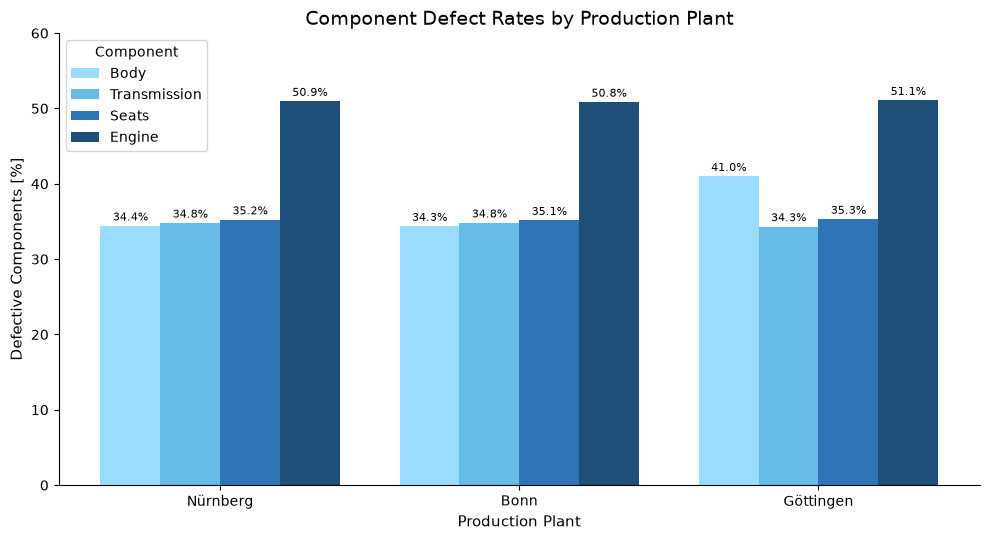

In [7]:
component_columns = {
    "Body": "Fehlerhaft_Karosserie",
    "Transmission": "Fehlerhaft_Schaltung",
    "Seats": "Fehlerhaft_Sitze",
    "Engine": "Fehlerhaft_Motor"
}

component_rows = []

for component, column in component_columns.items():
    summary = (
        vehicle_quality
        .groupby(
            "ORT_OEM",
            as_index=False
        )
        .agg(
            Defect_Rate=(
                column,
                "mean"
            )
        )
    )

    summary["Component"] = component

    component_rows.append(
        summary
    )

component_kpi = pd.concat(
    component_rows,
    ignore_index=True
)

component_kpi["Plant"] = (
    component_kpi["ORT_OEM"]
    .map(plant_names)
    .fillna(component_kpi["ORT_OEM"])
)

component_kpi["Defect_Rate_%"] = (
    component_kpi["Defect_Rate"]
    * 100
)

component_matrix = (
    component_kpi
    .pivot(
        index="Plant",
        columns="Component",
        values="Defect_Rate_%"
    )
    .reindex(
        index=plant_order,
        columns=[
            "Body",
            "Transmission",
            "Seats",
            "Engine"
        ]
    )
)

fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

x = np.arange(
    len(component_matrix.index)
)

width = 0.2

component_colors = [
    MAIN,
    MID,
    ACCENT,
    DARK
]

for i, component in enumerate(
    component_matrix.columns
):
    bars = ax.bar(
        x + (i - 1.5) * width,
        component_matrix[component],
        width,
        label=component,
        color=component_colors[i]
    )

    ax.bar_label(
        bars,
        fmt="%.1f%%",
        padding=2,
        fontsize=8
    )

ax.set_xticks(
    x,
    labels=component_matrix.index
)

ax.set_title(
    "Component Defect Rates by Production Plant"
)

ax.set_xlabel(
    "Production Plant"
)

ax.set_ylabel(
    "Defective Components [%]"
)

ax.set_ylim(
    0,
    60
)

ax.legend(
    title="Component"
)

plt.tight_layout()
plt.show()

The component profile is a diagnostic, not a separate audit KPI. It helps identify which part of the vehicle contributes most strongly to differences between production plants.

# Additional Insight 2 — Body Defects and Individual Parts

The body category shows the clearest plant-specific difference. The following table separates:

- defects marked directly on the body component
- defects originating from individual parts inside the body
- the total body defect status after defect propagation

In [8]:
body_source = (
    vehicle_quality
    .groupby(
        "ORT_OEM",
        as_index=False
    )
    .agg(
        Direct_Body_Defect_Rate=(
            "Fehlerhaft_Karosserie_Roh",
            "mean"
        ),
        Part_Derived_Body_Defect_Rate=(
            "Fehlerhaft_Karosserie_Einzelteil",
            "mean"
        ),
        Total_Body_Defect_Rate=(
            "Fehlerhaft_Karosserie",
            "mean"
        )
    )
)

body_source["Plant"] = (
    body_source["ORT_OEM"]
    .map(plant_names)
    .fillna(body_source["ORT_OEM"])
)

for column in [
    "Direct_Body_Defect_Rate",
    "Part_Derived_Body_Defect_Rate",
    "Total_Body_Defect_Rate"
]:
    body_source[
        f"{column}_%"
    ] = (
        body_source[column]
        * 100
    )

body_display = (
    body_source[
        [
            "Plant",
            "Direct_Body_Defect_Rate_%",
            "Part_Derived_Body_Defect_Rate_%",
            "Total_Body_Defect_Rate_%"
        ]
    ]
    .set_index("Plant")
    .loc[plant_order]
    .reset_index()
)

display(
    body_display.style.format(
        {
            "Direct_Body_Defect_Rate_%": "{:.2f}%",
            "Part_Derived_Body_Defect_Rate_%": "{:.2f}%",
            "Total_Body_Defect_Rate_%": "{:.2f}%"
        }
    )
)

,Plant,Direct_Body_Defect_Rate_%,Part_Derived_Body_Defect_Rate_%,Total_Body_Defect_Rate_%
0,Nürnberg,10.03%,27.09%,34.40%
1,Bonn,9.94%,27.11%,34.35%
2,Göttingen,10.00%,34.41%,40.98%


If the direct body defect rates are similar while the part-derived rate differs, the excess field defect burden is more likely associated with supplied individual parts than with the body component itself.

# Additional Insight 3 — Tier-1 Supplier Quality

The final dataset retains the Tier-1 production plant for each installed component. Direct component defect rates can therefore be compared across Tier-1 suppliers without reopening the raw production files.

The chart below shows the Tier-1 plant with the highest direct defect rate within each component group.

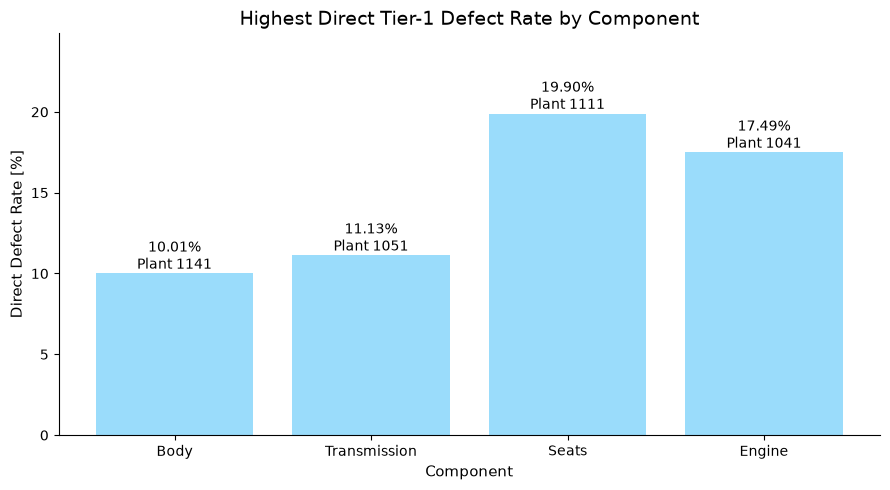

,Component,Tier1_Plant,Installed_Units,Direct_Defects,Direct_Defect_Rate_%
0,Body,1141,"1,442,476","144,350",10.01%
1,Transmission,1051,"997,114","110,966",11.13%
2,Seats,1111,"299,289","59,553",19.90%
3,Engine,1041,"808,595","141,447",17.49%


In [10]:
supplier_specs = {
    "Body": (
        "Tier1_Werksnummer_Karosserie",
        "Fehlerhaft_Karosserie_Roh"
    ),
    "Transmission": (
        "Tier1_Werksnummer_Schaltung",
        "Fehlerhaft_Schaltung_Roh"
    ),
    "Seats": (
        "Tier1_Werksnummer_Sitze",
        "Fehlerhaft_Sitze_Roh"
    ),
    "Engine": (
        "Tier1_Werksnummer_Motor",
        "Fehlerhaft_Motor_Roh"
    )
}

supplier_rows = []

for component, (
    plant_column,
    defect_column
) in supplier_specs.items():

    summary = (
        vehicle_quality
        .groupby(
            plant_column,
            as_index=False
        )
        .agg(
            Installed_Units=(
                defect_column,
                "size"
            ),
            Direct_Defects=(
                defect_column,
                "sum"
            )
        )
        .rename(
            columns={
                plant_column:
                    "Tier1_Plant"
            }
        )
    )

    summary["Component"] = component

    summary["Direct_Defect_Rate_%"] = (
        summary["Direct_Defects"]
        / summary["Installed_Units"]
        * 100
    )

    supplier_rows.append(summary)

tier1_supplier = pd.concat(
    supplier_rows,
    ignore_index=True
)

component_order = [
    "Body",
    "Transmission",
    "Seats",
    "Engine"
]

worst_supplier = (
    tier1_supplier
    .sort_values(
        "Direct_Defect_Rate_%",
        ascending=False
    )
    .groupby(
        "Component",
        as_index=False
    )
    .head(1)
    .set_index(
        "Component"
    )
    .loc[
        component_order
    ]
    .reset_index()
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars = ax.bar(
    worst_supplier["Component"],
    worst_supplier[
        "Direct_Defect_Rate_%"
    ],
    color=MAIN
)

ax.set_title(
    "Highest Direct Tier-1 Defect Rate by Component"
)

ax.set_xlabel(
    "Component"
)

ax.set_ylabel(
    "Direct Defect Rate [%]"
)

ax.set_ylim(
    0,
    worst_supplier[
        "Direct_Defect_Rate_%"
    ].max() * 1.25
)

for bar, rate, plant in zip(
    bars,
    worst_supplier[
        "Direct_Defect_Rate_%"
    ],
    worst_supplier[
        "Tier1_Plant"
    ]
):
    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.2f}%\nPlant {plant}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

display(
    worst_supplier[
        [
            "Component",
            "Tier1_Plant",
            "Installed_Units",
            "Direct_Defects",
            "Direct_Defect_Rate_%"
        ]
    ]
    .style.format(
        {
            "Installed_Units": "{:,.0f}",
            "Direct_Defects": "{:,.0f}",
            "Direct_Defect_Rate_%": "{:.2f}%"
        }
    )
)

# Final Audit Recommendation

The production-plant audit recommendation is based on the required field KPIs. The supplier and component analyses are used to define the audit scope and identify likely upstream contributors.

In [11]:
candidate = plant_kpi.loc[
    plant_kpi["Defect_Rate_%"].idxmax()
]

absolute_leader = plant_kpi.loc[
    plant_kpi["Defective_Vehicles"].idxmax()
]

component_excess = (
    component_matrix
    .loc[candidate["Plant"]]
    - component_matrix.drop(
        index=candidate["Plant"]
    ).mean()
)

largest_excess_component = (
    component_excess.idxmax()
)

recommendation = (
    f"### Recommended next process audit: **{candidate['Plant']}**\n\n"
    f"- **{absolute_leader['Plant']}** has the largest absolute field defect burden with "
    f"**{absolute_leader['Defective_Vehicles']:,.0f}** defective vehicles.\n"
    f"- **{candidate['Plant']}** has the highest relative field defect frequency at "
    f"**{candidate['Defect_Rate_%']:.2f}%**.\n"
    f"- Because the relative frequency controls for production volume, "
    f"**{candidate['Plant']}** is the stronger process-audit candidate.\n"
    f"- The largest component-level excess at {candidate['Plant']} is observed in "
    f"**{largest_excess_component}**, which should be included in the audit drill-down."
)

display(
    Markdown(
        recommendation
    )
)

### Recommended next process audit: **Göttingen**

- **Nürnberg** has the largest absolute field defect burden with **1,041,102** defective vehicles.
- **Göttingen** has the highest relative field defect frequency at **88.98%**.
- Because the relative frequency controls for production volume, **Göttingen** is the stronger process-audit candidate.
- The largest component-level excess at Göttingen is observed in **Body**, which should be included in the audit drill-down.

# Final Dataset Preview

The eventual app should include a table page for the final dataset. The notebook shows a small preview only.

In [12]:
print(
    "Final dataset shape:",
    vehicle_quality.shape
)

display(
    vehicle_quality.head(20)
)

Final dataset shape: (2489518, 48)


,ID_Fahrzeug,OEM,Fahrzeugtyp,Produktionsdatum,Herstellernummer,Werksnummer_OEM,ORT_OEM,PLZ_OEM,Breitengrad_OEM,Laengengrad_OEM,...,Anzahl_Pruefobjekte,Fehlerhaft_Gesamt,Fehlerhaft_Datum,Fehlerhaft_Fahrleistung,Gemeinde_Zulassung,Zulassungsdatum,PLZ_Gemeinde,Breitengrad_Gemeinde,Laengengrad_Gemeinde,Direkte_Fehlerrate
0,11-1-11-1,OEM1,Type11,2008-11-18,1,11,NUERNBERG,90491,49.46699,11.107353,...,18,1,NaT,0,DRESDEN,2009-01-01,1067.0,51.051697,13.736883,0.166667
1,11-1-11-2,OEM1,Type11,2008-11-18,1,11,NUERNBERG,90491,49.46699,11.107353,...,18,1,NaT,0,DRESDEN,2009-01-01,1067.0,51.051697,13.736883,0.222222
2,11-1-11-3,OEM1,Type11,2008-11-19,1,11,NUERNBERG,90491,49.46699,11.107353,...,18,1,NaT,0,KOELN,2009-01-01,50667.0,50.938107,6.957068,0.055556
3,11-1-11-4,OEM1,Type11,2008-11-19,1,11,NUERNBERG,90491,49.46699,11.107353,...,18,1,NaT,0,KOELN,2009-01-01,50667.0,50.938107,6.957068,0.166667
4,11-1-11-5,OEM1,Type11,2008-11-19,1,11,NUERNBERG,90491,49.46699,11.107353,...,18,1,NaT,0,KOELN,2009-01-01,50667.0,50.938107,6.957068,0.166667
5,11-1-11-6,OEM1,Type11,2008-11-19,1,11,NUERNBERG,90491,49.46699,11.107353,...,18,1,NaT,0,KOELN,2009-01-01,50667.0,50.938107,6.957068,0.111111
6,11-1-11-7,OEM1,Type11,2008-11-19,1,11,NUERNBERG,90491,49.46699,11.107353,...,18,1,NaT,0,KOELN,2009-01-01,50667.0,50.938107,6.957068,0.111111
7,11-1-11-8,OEM1,Type11,2008-11-19,1,11,NUERNBERG,90491,49.46699,11.107353,...,18,1,NaT,0,KOELN,2009-01-01,50667.0,50.938107,6.957068,0.166667
8,11-1-11-9,OEM1,Type11,2008-11-19,1,11,NUERNBERG,90491,49.46699,11.107353,...,18,1,2010-03-16,44951,KOELN,2009-01-01,50667.0,50.938107,6.957068,0.055556
9,11-1-11-10,OEM1,Type11,2008-11-19,1,11,NUERNBERG,90491,49.46699,11.107353,...,18,0,NaT,0,KOELN,2009-01-01,50667.0,50.938107,6.957068,0.000000
